## Notebook 14 – Statistics in Machine Learning

### Installing the Libraries
I am installing scikit-learn for the machine learning models and metrics, scipy for the statistics functions, and numpy, pandas, matplotlib and seaborn for handling the data and drawing the charts.

In [1]:
!pip install numpy pandas matplotlib seaborn scipy scikit-learn

### Importing the Libraries

In [2]:
import numpy as np                # for numeric calculations
import pandas as pd               # for storing the data in tables
import matplotlib.pyplot as plt   # for the basic charts
import seaborn as sns             # for the heatmap
from scipy.stats import norm      # for drawing normal curves in Naive Bayes

# data preparation, models and metrics from scikit-learn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score,
                             confusion_matrix, classification_report, silhouette_score)

# keeping all charts at a similar size so they look consistent
plt.rcParams["figure.figsize"] = (6, 4)

### Sample Dataset
For this notebook I created one student dataset with 300 students and I use it for almost every topic. The columns are `study_hours`, `attendance`, `sleep_hours`, `previous_marks`, `age`, `department`, the final `marks` (used as the target for regression) and `passed` (1 if marks are 65 or more, used as the target for classification).

I added some problems to the data on purpose (5 duplicate rows, missing values, 2 impossible sleep values and 3 extreme study hours), so the first three topics can clean it step by step. The later topics then use the cleaned data. The only exception is the Recommendation Systems topic, which needs a small ratings table of its own.

In [3]:
np.random.seed(42)
n = 300

study_hours = np.random.normal(5, 1.5, n).clip(0.5, 10).round(1)
attendance = (60 + study_hours * 4 + np.random.normal(0, 6, n)).clip(40, 100).round(1)
sleep_hours = np.random.normal(7, 1, n).clip(4, 10).round(1)
previous_marks = (30 + study_hours * 5 + np.random.normal(0, 8, n)).clip(0, 100).round(1)
age = np.random.randint(18, 25, n)
department = np.random.choice(["CSE", "ECE", "Mechanical", "Civil"], n)

# marks depend mainly on study hours, attendance and previous marks, plus some random noise
marks = (15 + study_hours * 5 + attendance * 0.2 + previous_marks * 0.25 + np.random.normal(0, 6, n)).clip(0, 100).round(1)
passed = (marks >= 65).astype(int)

raw_df = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "sleep_hours": sleep_hours,
    "previous_marks": previous_marks,
    "age": age,
    "department": department,
    "marks": marks,
    "passed": passed
})

# adding problems to the data on purpose
raw_df.loc[np.random.choice(raw_df.index, 25, replace=False), "attendance"] = np.nan    # missing attendance
raw_df.loc[np.random.choice(raw_df.index, 15, replace=False), "sleep_hours"] = np.nan   # missing sleep hours
raw_df.loc[[10, 50], "sleep_hours"] = 25                                                # impossible values
raw_df.loc[[20, 80, 120], "study_hours"] = [18.5, 20.0, 16.0]                           # extreme values
raw_df = pd.concat([raw_df, raw_df.sample(5, random_state=1)], ignore_index=True)       # 5 duplicate rows

# working on a copy, so raw_df stays unchanged
df = raw_df.copy()
df.head()

,study_hours,attendance,sleep_hours,previous_marks,age,department,marks,passed
0,5.7,77.8,7.8,61.4,22,Mechanical,71.2,1
1,4.8,75.8,NaN,50.9,19,Civil,68.8,1
2,6.0,88.5,7.9,60.2,24,Mechanical,74.1,1
3,7.3,92.9,8.4,76.7,20,CSE,90.9,1
4,4.6,78.3,7.4,54.5,22,Mechanical,67.2,1


**What this does:** It creates 300 students where marks depend mainly on study hours, attendance and previous marks. Age and department are random, so they should not matter much for marks. After that it damages the data in a few controlled ways, so there is something real to clean. From now on I work on `df`, a copy of the raw data.

## Data Cleaning

### Concept
Data cleaning means fixing the problems in raw data before using it, like duplicate rows, impossible values and wrong data types. Statistics helps a lot here. Summary statistics like count, minimum and maximum show which values look wrong, and counting duplicates shows how many rows would be counted twice and push the results in the wrong direction.

### Example
In this dataset there are 5 duplicate rows and 2 students with a sleep time of 25 hours, which is impossible in a day. If I leave them in, the averages and the model would be built on wrong information.

### Python Implementation

In [4]:
print("Shape of raw data:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Highest sleep_hours value:", df["sleep_hours"].max())

# removing the duplicate rows
df = df.drop_duplicates()

# sleeping more than 12 hours is not realistic here (25 is even impossible), so I treat these as wrong
# and set them to missing instead of guessing the real value
wrong_sleep = (df["sleep_hours"] > 12).sum()
df.loc[df["sleep_hours"] > 12, "sleep_hours"] = np.nan

print("Wrong sleep_hours values set to missing:", wrong_sleep)
print("Shape after cleaning:", df.shape)

Shape of raw data: (305, 8)
Duplicate rows: 5
Highest sleep_hours value: 25.0
Wrong sleep_hours values set to missing: 2
Shape after cleaning: (300, 8)


#### What the program does
The program first checks the size of the data, counts the duplicate rows and looks at the highest sleep value, which immediately shows the problem (25 hours). Then it removes the duplicates and replaces the impossible sleep values with missing values (NaN), so they can be handled in the next step instead of being used as real data. The data goes from 305 rows to 300 rows.

#### Advantages
- Makes every later statistic and model more reliable.

#### Limitations
- Deciding what counts as 'wrong' needs judgement, for example the cutoff of 12 hours here is my own choice.

#### Key Point
Data cleaning uses simple statistics like min, max and counts to find problems before they spoil the analysis.

## Missing Value Handling

### Concept
Missing values are empty cells in the data, and most models cannot work with them. The simplest solution is to fill them with a typical value of that column, which is where statistics comes in: the mean, median or mode. For numeric columns the median is usually safer because it is not pulled by extreme values, and for categorical columns the mode (most frequent value) is used. The percentage of missing values also helps to decide whether to fill a column or drop it.

### Example
After the last step, attendance is missing for 25 students (8.3%) and sleep_hours for 17 students (5.7%, which includes the 2 impossible values I removed). These are small percentages, so it is better to fill them than to throw away those students.

### Python Implementation

In [5]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df) * 100).round(1)
print(pd.DataFrame({"missing": missing_count, "percent": missing_percent})[missing_count > 0])

# comparing mean and median before choosing one
print("attendance  mean:", round(df["attendance"].mean(), 2), " median:", df["attendance"].median())
print("sleep_hours mean:", round(df["sleep_hours"].mean(), 2), " median:", df["sleep_hours"].median())

# filling the missing values with the median of each column
for col in ["attendance", "sleep_hours"]:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after filling:", df.isna().sum().sum())

             missing  percent
attendance        25      8.3
sleep_hours       17      5.7
attendance  mean: 79.83  median: 79.7
sleep_hours mean: 7.08  median: 7.0
Missing values after filling: 0


#### What the program does
The program counts the missing values in every column and also shows them as a percentage. It then compares the mean and the median of the two columns, and fills the gaps with the median. At the end it confirms that no missing values are left.

#### Advantages
- Keeps all the students in the data instead of deleting rows.
- Median filling is simple and is not affected by outliers.

#### Limitations
- Every filled value is just a typical value, so it reduces the natural variation of the column a little.
- It works well only when few values are missing.

#### Key Point
Missing values are filled using statistics of the column itself (median for numbers, mode for categories), and the percentage missing tells us if filling is reasonable.

## Outlier Detection

### Concept
Outliers are values that are far away from the rest of the data. The IQR method (using the quartiles) and the Z-score method (using the mean and standard deviation) are the two common statistical ways to find them, as covered in Notebook 9. In machine learning, outliers can pull a regression line or the scaling of a feature, so they are either removed or capped.

### Example
In this data, three students have study hours of 16, 18.5 and 20 hours a day, which is not realistic. I want to see which method finds them, and then cap them instead of deleting the students.

### Python Implementation

Bounds: 1.11 to 8.81
Outliers by IQR method: [0.5, 1.1, 9.1, 10.0, 16.0, 18.5, 20.0]
Outliers by Z-score (|z| > 3): [16.0, 18.5, 20.0]


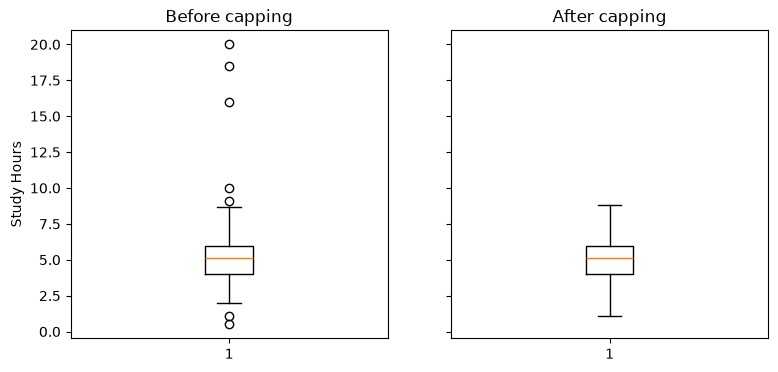

In [6]:
q1 = df["study_hours"].quantile(0.25)
q3 = df["study_hours"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_iqr = df[(df["study_hours"] < lower_bound) | (df["study_hours"] > upper_bound)]["study_hours"]
print("Bounds:", round(lower_bound, 2), "to", round(upper_bound, 2))
print("Outliers by IQR method:", sorted(outliers_iqr.tolist()))

z_scores = (df["study_hours"] - df["study_hours"].mean()) / df["study_hours"].std()
print("Outliers by Z-score (|z| > 3):", sorted(df.loc[z_scores.abs() > 3, "study_hours"].tolist()))

# capping the values at the bounds instead of deleting the rows
before = df["study_hours"].copy()
df["study_hours"] = df["study_hours"].clip(lower_bound, upper_bound)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
axes[0].boxplot(before)
axes[0].set_title("Before capping")
axes[0].set_ylabel("Study Hours")
axes[1].boxplot(df["study_hours"])
axes[1].set_title("After capping")
plt.show()

#### What the program does
The program calculates Q1, Q3 and the IQR, builds the lower and upper bounds with the 1.5 x IQR rule, and lists the values outside them. It also finds the outliers with the Z-score method for comparison. Then it caps the values at the bounds using `clip()`, and draws a box plot before and after.

#### Why the graph looks like this
In the left box plot the box is small and sits around 4 to 6 hours, and there are dots far above it (16, 18.5, 20) plus a few smaller dots near the top and bottom. That is because most students study a normal amount and a few values are very far from them. In the right box plot there are no dots left, because every value outside the bounds was moved to the bound itself, so the whiskers now end at about 1.1 and 8.8 hours.

#### Advantages
- IQR method is not affected by the outliers it is trying to find.
- Capping keeps all the students in the data.

#### Limitations
- The 1.5 x IQR rule is a convention, so it also flagged a few small values like 0.5, 1.1, 9.1 and 10.0 that may be real students.
- Capping changes the real values.

#### Interpretation
IQR flagged 7 values but the Z-score flagged only the 3 extreme ones, because the extreme values themselves increase the mean and standard deviation that the Z-score depends on.

## Feature Engineering

### Concept
Feature engineering means creating new features from the existing ones, or converting them into a form a model can use, like turning a category into numbers. Statistics is used to check if the new feature is actually useful, mostly by looking at its correlation with the target, and to encode categories (one-hot encoding creates a 0/1 column for each category).

### Example
Study hours and attendance both relate to marks, so I combine them into one feature, `study_attendance_score = study_hours x attendance / 100`, which is like the 'effective' hours studied. The `department` column is text, so I convert it into 0/1 columns.

### Python Implementation

In [7]:
print("Correlation with marks before creating the new feature:")
print(df[["study_hours", "attendance"]].corrwith(df["marks"]).round(3))

df["study_attendance_score"] = (df["study_hours"] * df["attendance"] / 100).round(2)
print("Correlation of study_attendance_score with marks:", round(df["study_attendance_score"].corr(df["marks"]), 3))

# one-hot encoding the department column (CSE becomes the reference group)
df = pd.get_dummies(df, columns=["department"], drop_first=True, dtype=int)
print(df.columns.tolist())

Correlation with marks before creating the new feature:
study_hours    0.838
attendance     0.629
dtype: float64
Correlation of study_attendance_score with marks: 0.84
['study_hours', 'attendance', 'sleep_hours', 'previous_marks', 'age', 'marks', 'passed', 'study_attendance_score', 'department_Civil', 'department_ECE', 'department_Mechanical']


#### What the program does
The program prints how strongly study hours and attendance are correlated with marks, creates the combined feature and checks its correlation too. Then `get_dummies()` replaces the department column with three 0/1 columns. `drop_first=True` removes one category (CSE), since it can be worked out from the other three.

#### Advantages
- Can give the model information in a more useful form.
- Encoding makes categorical data usable for models.

#### Limitations
- A new feature is not automatically useful. Here the new score has a correlation of about 0.84, which is almost the same as study_hours alone (0.84), so it adds very little new information, and it is also highly related to the two features it was made from.

#### Key Point
Always check a new feature with a statistic like correlation, because creating it does not guarantee it helps.

## Feature Scaling

### Concept
Feature scaling puts the features on a similar scale so that no feature dominates just because it has bigger numbers. Standardization uses the mean and standard deviation: z = (x - mean) / standard deviation. After this, every feature has a mean of 0 and a standard deviation of 1. It is important for models that use distances or gradients, like K-Means, PCA and logistic regression.

### Example
Study hours go from about 1 to 9, while previous marks go from about 21 to 95. If I used them directly in K-Means (which uses distance), previous marks would dominate only because its numbers are bigger, not because it is more important.

### Python Implementation

Before scaling:
      study_hours  attendance  sleep_hours  previous_marks
mean         5.01       79.82         7.07           55.72
std          1.48        7.71         0.97           11.24
min          1.11       58.00         4.30           21.40
max          8.81      100.00         9.60           95.30
After scaling:
      study_hours  attendance  sleep_hours  previous_marks
mean        -0.00       -0.00        -0.00            0.00
std          1.00        1.00         1.00            1.00
min         -2.63       -2.83        -2.87           -3.06
max          2.56        2.62         2.61            3.53


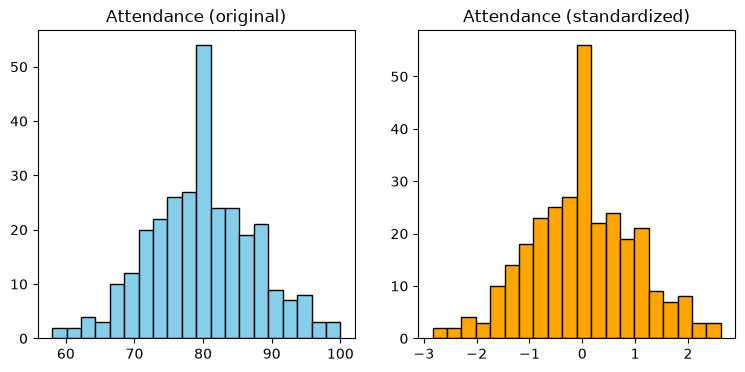

In [8]:
numeric_cols = ["study_hours", "attendance", "sleep_hours", "previous_marks"]

scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)

print("Before scaling:")
print(df[numeric_cols].agg(["mean", "std", "min", "max"]).round(2))
print("After scaling:")
print(scaled.agg(["mean", "std", "min", "max"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].hist(df["attendance"], bins=20, color="skyblue", edgecolor="black")
axes[0].set_title("Attendance (original)")
axes[1].hist(scaled["attendance"], bins=20, color="orange", edgecolor="black")
axes[1].set_title("Attendance (standardized)")
plt.show()

#### What the program does
The program standardizes four numeric columns with `StandardScaler`, then prints the mean, standard deviation, minimum and maximum before and after. After scaling, every column has a mean of about 0 and a standard deviation of 1. The two histograms show attendance before and after.

#### Why the graph looks like this
Both histograms have exactly the same shape, because standardization only shifts and stretches the values, it does not change the distribution. The only difference is the x-axis: the original attendance is centred around 80 and goes from 58 to 100, while the standardized one is centred at 0 and goes from about -2.8 to 2.6.

#### Advantages
- Stops large-scale features from dominating distance-based and gradient-based models.
- Keeps the shape of the distribution.

#### Limitations
- It is affected by outliers (since mean and standard deviation are), which is why outliers were handled first.
- Tree-based models do not need it.

#### Key Point
Standardization turns every feature into 'how many standard deviations from the mean', so all features can be compared fairly. The scaler should be fitted on the training data only to avoid data leakage.

## Data Normalization

### Concept
Normalization (min-max scaling) squeezes every value into the range 0 to 1 using the minimum and maximum of the column: x_new = (x - min) / (max - min). It is different from standardization, which centres the data around 0. Min-max scaling is common for neural networks and for data like image pixels where a fixed range is useful.

### Example
If previous marks go from 21.4 to 95.3, then a student with 58.4 marks gets (58.4 - 21.4) / (95.3 - 21.4) = 0.5, exactly in the middle of the range.

### Python Implementation

In [9]:
minmax = MinMaxScaler()
normalized = pd.DataFrame(minmax.fit_transform(df[numeric_cols]), columns=numeric_cols)
print(normalized.agg(["min", "max"]).round(2))

# checking why outliers matter for min-max scaling: same column with and without capping
raw_study = raw_df.drop_duplicates()[["study_hours"]]
print("Median study_hours after min-max WITHOUT capping outliers:", round(float(np.median(MinMaxScaler().fit_transform(raw_study))), 3))
print("Median study_hours after min-max WITH capping outliers:   ", round(float(np.median(MinMaxScaler().fit_transform(df[["study_hours"]]))), 3))

     study_hours  attendance  sleep_hours  previous_marks
min          0.0         0.0          0.0             0.0
max          1.0         1.0          1.0             1.0
Median study_hours after min-max WITHOUT capping outliers: 0.236
Median study_hours after min-max WITH capping outliers:    0.518


#### What the program does
The program applies `MinMaxScaler` to the same four columns and prints the minimum and maximum, which are now exactly 0 and 1 for every column. The second part scales study hours twice, once using the raw data with the extreme values and once using the capped data, to show how much an outlier changes the result.

#### Advantages
- Gives every feature the same fixed range of 0 to 1.
- Easy to understand and to reverse.

#### Limitations
- Very sensitive to outliers, because the minimum and maximum decide the scale. Without capping, the median student gets about 0.24 because of the 20-hour value, but after capping the median student gets about 0.52, which is where it should be.

#### Key Point
Normalization uses the min and max of a column, so it should be done after handling outliers.

## Model Evaluation

### Concept
Model evaluation checks how well a model works on data it has not seen before. For this, the data is split into training and test sets, and the metrics are calculated on the test set. For regression the common ones are MAE (average error), RMSE (typical error, punishes big errors more) and R-squared (the share of variation in the target that the model explains). Cross-validation repeats the split several times to see how stable the result is. A baseline that just predicts the average is used for comparison.

### Example
A model that always predicts the average marks is the simplest baseline. If my real model cannot do better than this, then it has learned nothing useful.

### Python Implementation

In [10]:
feature_cols = [c for c in df.columns if c not in ("marks", "passed")]
X = df[feature_cols]
y = df["marks"]
y_class = df["passed"]

X_train, X_test, y_train, y_test, yc_train, yc_test = train_test_split(X, y, y_class, test_size=0.2, random_state=42)
print("Training rows:", len(X_train), " Test rows:", len(X_test))

# baseline: always predict the average marks of the training data
baseline_pred = np.full(len(y_test), y_train.mean())
model = LinearRegression().fit(X_train, y_train)
model_pred = model.predict(X_test)

def show_metrics(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    print(f"{name:20s} MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.3f}")

show_metrics("Baseline (mean)", y_test, baseline_pred)
show_metrics("Linear Regression", y_test, model_pred)

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print("5-fold CV R2 scores:", cv_scores.round(3))
print("Mean R2:", round(cv_scores.mean(), 3), " Std:", round(cv_scores.std(), 3))
print("Train R2:", round(model.score(X_train, y_train), 3))

Training rows: 240  Test rows: 60
Baseline (mean)      MAE: 8.52  RMSE: 10.52  R2: -0.006
Linear Regression    MAE: 4.37  RMSE: 5.34  R2: 0.741
5-fold CV R2 scores: [0.571 0.668 0.751 0.777 0.796]
Mean R2: 0.713  Std: 0.083
Train R2: 0.756


#### What the program does
The program splits the data 80/20 into training and test sets (the same split is reused in the next topics), then compares the baseline with a linear regression using MAE, RMSE and R-squared on the test set. It also runs 5-fold cross-validation and prints the training R-squared to compare with the test result.

#### Advantages
- Gives an honest estimate of performance on new data.
- Comparing with a baseline shows if the model is really learning.

#### Limitations
- A single train/test split depends on which students land in the test set, as the cross-validation scores below show.

#### Interpretation
The baseline has R-squared of about 0 and an RMSE of 10.5 (which is just the spread of marks), while linear regression gets an RMSE of 5.3 and R-squared of 0.74, so it explains about 74% of the variation in marks. Training R-squared (0.756) and test R-squared (0.741) are close, so there is little overfitting, but the 5 cross-validation scores range from 0.57 to 0.80, so the single split result is not exact.

## Linear Regression

### Concept
Linear regression predicts a number by fitting a straight line (or a flat plane for many features) through the data. It uses the least squares method, which chooses the coefficients that make the sum of squared errors as small as possible. Each coefficient says how much the target changes when that feature increases by 1 and the others stay the same. The errors (residuals) should be centred around 0 and have a similar spread everywhere. Statistics like correlation, R-squared and residual analysis are used to judge it.

### Example
Predicting the final marks of a student from study hours, attendance, previous marks and the other features.

### Python Implementation

Intercept: 11.81
study_hours               4.104
department_Civil         -2.361
department_ECE           -1.756
department_Mechanical    -0.521
previous_marks            0.285
attendance                0.264
sleep_hours              -0.251
age                       0.162
study_attendance_score   -0.024
dtype: float64
Mean of residuals: 0.116
Std of residuals: 5.38


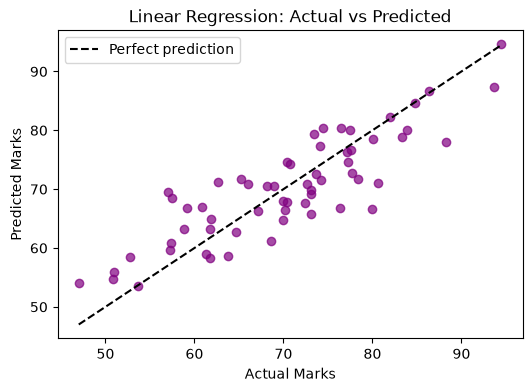

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

coefficients = pd.Series(lr.coef_, index=feature_cols).round(3).sort_values(key=abs, ascending=False)
print("Intercept:", round(lr.intercept_, 2))
print(coefficients)

predictions = lr.predict(X_test)
residuals = y_test - predictions
print("Mean of residuals:", round(residuals.mean(), 3))
print("Std of residuals:", round(residuals.std(), 2))

plt.scatter(y_test, predictions, alpha=0.7, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", label="Perfect prediction")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

#### What the program does
The program fits the model on the training data and prints the intercept and the coefficients sorted by size. Then it predicts the test marks and calculates the residuals (actual minus predicted) to check their mean and spread. The scatter plot compares the actual and the predicted marks, with a dashed line showing perfect predictions.

#### Why the graph looks like this
The points follow the dashed line closely, going from bottom left to top right, which means the predictions are close to the actual marks. They are not exactly on the line, and the vertical spread of about 5 marks is the same as the residual standard deviation (5.38). The spread exists because marks also contain random noise that no feature can explain, which is why R-squared is 0.74 and not 1. The points at the low end are slightly above the line and the ones at the high end are slightly below it, because predictions are always pulled a little toward the average.

#### Advantages
- Simple, fast and easy to explain, because the coefficients have a clear meaning.

#### Limitations
- Only captures straight-line relationships.
- Correlated features share the effect between them, so single coefficients are harder to trust. In this data, marks were generated using about 5 marks per study hour, but the model gives about 4.1 because attendance and previous marks also depend on study hours.

#### Interpretation
The biggest coefficient is study_hours at about 4.1, which means one extra hour of study adds about 4.1 marks when everything else stays the same. Previous marks (0.29) and attendance (0.26) matter much less per unit. The coefficients for age, sleep and department are small, which is correct since I generated them randomly, and the engineered score has a coefficient close to 0 (-0.02), because study_hours and attendance already carry its information. The residual mean is about 0.1, close to 0 as it should be.

## Logistic Regression

### Concept
Logistic regression is used when the target is a category (like pass or fail). It first calculates a score z from the features, like linear regression does, and then passes it through the sigmoid function p = 1 / (1 + e^(-z)), which turns any number into a probability between 0 and 1. If the probability is above 0.5, the class is predicted as 1. Statistics is used in the probabilities and odds, and in classification metrics like accuracy, precision, recall and the confusion matrix.

### Example
Predicting whether a student passes (marks of 65 or more) from the same features. I standardize the features first, because logistic regression works better when the features are on the same scale.

### Python Implementation

Accuracy: 0.85
Accuracy if we always predict 'pass': 0.683
Confusion matrix (rows = actual, columns = predicted):
[[14  5]
 [ 4 37]]
              precision    recall  f1-score   support

           0      0.778     0.737     0.757        19
           1      0.881     0.902     0.892        41

    accuracy                          0.850        60
   macro avg      0.829     0.820     0.824        60
weighted avg      0.848     0.850     0.849        60

study_hours               1.05
attendance                0.56
sleep_hours               0.08
previous_marks            1.17
age                       0.02
study_attendance_score    0.91
department_Civil         -0.16
department_ECE           -0.16
department_Mechanical     0.05
dtype: float64


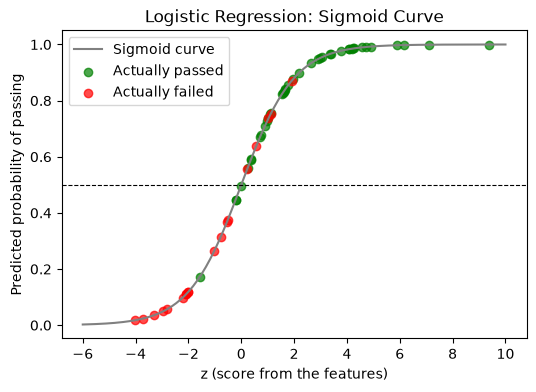

In [12]:
log_model = make_pipeline(StandardScaler(), LogisticRegression())
log_model.fit(X_train, yc_train)

pred_class = log_model.predict(X_test)
print("Accuracy:", round(accuracy_score(yc_test, pred_class), 3))
print("Accuracy if we always predict 'pass':", round(yc_test.mean(), 3))
print("Confusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(yc_test, pred_class))
print(classification_report(yc_test, pred_class, digits=3))
print(pd.Series(log_model[-1].coef_[0], index=feature_cols).round(2))

z = log_model.decision_function(X_test)
prob = log_model.predict_proba(X_test)[:, 1]
z_line = np.linspace(-6, 10, 200)

plt.plot(z_line, 1 / (1 + np.exp(-z_line)), color="gray", label="Sigmoid curve")
plt.scatter(z[yc_test == 1], prob[yc_test == 1], color="green", alpha=0.7, label="Actually passed")
plt.scatter(z[yc_test == 0], prob[yc_test == 0], color="red", alpha=0.7, label="Actually failed")
plt.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("z (score from the features)")
plt.ylabel("Predicted probability of passing")
plt.title("Logistic Regression: Sigmoid Curve")
plt.legend()
plt.show()

#### What the program does
The program builds a pipeline that scales the features and fits a logistic regression, then prints accuracy, the confusion matrix and the classification report. It also compares accuracy with a model that always predicts 'pass'. The chart plots the score z of each test student against its predicted probability, on top of the sigmoid curve.

#### Why the graph looks like this
All the points lie exactly on the S-shaped curve, because the predicted probability is just the sigmoid function applied to z. Students with a very low z get a probability close to 0 and mostly turn out to be red (failed), and students with a high z get a probability close to 1 and are mostly green (passed). The mistakes (red points on the high side and green points on the low side) happen in the middle part of the curve, where the probability is not close to 0 or 1 and the model is not sure.

#### Advantages
- Gives probabilities, not just a yes or no.
- The coefficients can be interpreted, and it is a strong first model for classification.

#### Limitations
- Assumes a straight-line relationship between the features and the log-odds.
- Accuracy alone can be misleading when the classes are not balanced.

#### Interpretation
The model gets 85% accuracy, compared to 68.3% for always predicting 'pass', so it has learned something real. The confusion matrix shows 37 correct passes, 14 correct fails, 5 students wrongly predicted as pass and 4 wrongly predicted as fail. For the 'pass' class precision is 0.88 and recall is 0.90, while for 'fail' recall is lower (0.74), as there are fewer failed students to learn from. The largest coefficients are for previous_marks, study_hours and the engineered score, while age, sleep and department are close to 0.

## Naive Bayes

### Concept
Naive Bayes is a classifier built directly on Bayes' theorem (Notebook 5): P(class | features) is proportional to P(class) x P(feature 1 | class) x P(feature 2 | class) x ... It is called 'naive' because it assumes that all the features are independent of each other given the class, which makes the maths simple. In Gaussian Naive Bayes, each feature in each class is described by a normal distribution using its mean and variance.

### Example
For each student, the model starts with the prior probability of passing and then multiplies it with how likely this student's study hours, attendance and so on are for a student who passed, and for a student who failed. The class with the bigger result is the prediction.

### Python Implementation

Accuracy: 0.8
Prior probabilities (failed, passed): [0.388 0.612]
Mean study_hours (failed, passed): [3.67 5.8 ]


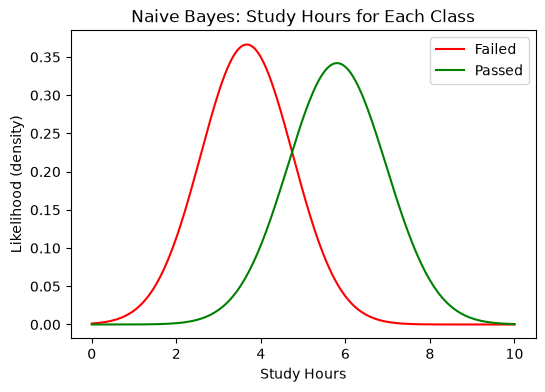

In [13]:
nb_model = GaussianNB()
nb_model.fit(X_train, yc_train)

nb_pred = nb_model.predict(X_test)
print("Accuracy:", round(accuracy_score(yc_test, nb_pred), 3))
print("Prior probabilities (failed, passed):", nb_model.class_prior_.round(3))

idx = feature_cols.index("study_hours")
print("Mean study_hours (failed, passed):", nb_model.theta_[:, idx].round(2))

x_axis = np.linspace(0, 10, 200)
for label, color, name in [(0, "red", "Failed"), (1, "green", "Passed")]:
    std = np.sqrt(nb_model.var_[label, idx])
    plt.plot(x_axis, norm.pdf(x_axis, nb_model.theta_[label, idx], std), color=color, label=name)

plt.xlabel("Study Hours")
plt.ylabel("Likelihood (density)")
plt.title("Naive Bayes: Study Hours for Each Class")
plt.legend()
plt.show()

#### What the program does
The program fits a Gaussian Naive Bayes model and prints its accuracy and the prior probabilities of each class (learned from the training data). It then reads the mean and variance that the model stored for study hours in each class, and draws the normal curve it uses for the failed and the passed students.

#### Why the graph looks like this
There are two bell curves, one for each class. The green curve (passed) is centred at about 5.8 study hours and the red curve (failed) at about 3.7, because students who passed study more on average. Where the green curve is higher than the red one, the model prefers 'passed', and where the red one is higher it prefers 'failed'. The curves overlap in the middle (around 4 to 5 hours), and this overlap is why the model sometimes makes mistakes.

#### Advantages
- Very fast, works with small data and is simple to explain with Bayes' theorem.

#### Limitations
- The independence assumption is not true for this data, because study hours, attendance, previous marks and the engineered score are all correlated, so the probabilities are not very reliable.

#### Interpretation
The accuracy is 80%, lower than the 85% of logistic regression on the same data, and that is expected because Naive Bayes treats correlated features as independent evidence and counts the same information several times. The priors are 0.39 for failed and 0.61 for passed, which match the share of each class in the training data.

## Clustering

### Concept
Clustering is unsupervised learning, which means there is no target column and the algorithm groups similar rows by itself. K-Means picks k centres (centroids, which are the mean of each group) and puts every student in the nearest one, trying to make the variation inside the clusters (inertia) as small as possible. Statistics is used for the means, variance and distances, and for the silhouette score, which tells how well separated the clusters are (from -1 to 1). Because it uses distance, the features must be scaled first.

### Example
Grouping the students by their study habits (study hours, attendance, previous marks and sleep hours) to find types of students, without using the marks or the pass/fail result.

### Python Implementation

Inertia for k = 1 to 6: [1200.   774.   643.8  550.3  492.3  447.4]
Silhouette for k = 2 to 6: [0.296 0.23  0.225 0.208 0.21 ]
Best k: 2
         study_hours  attendance  previous_marks  sleep_hours
cluster                                                      
0                6.2        84.8            63.7          7.1
1                3.9        75.2            48.4          7.1
Students in each cluster: {0: 144, 1: 156}


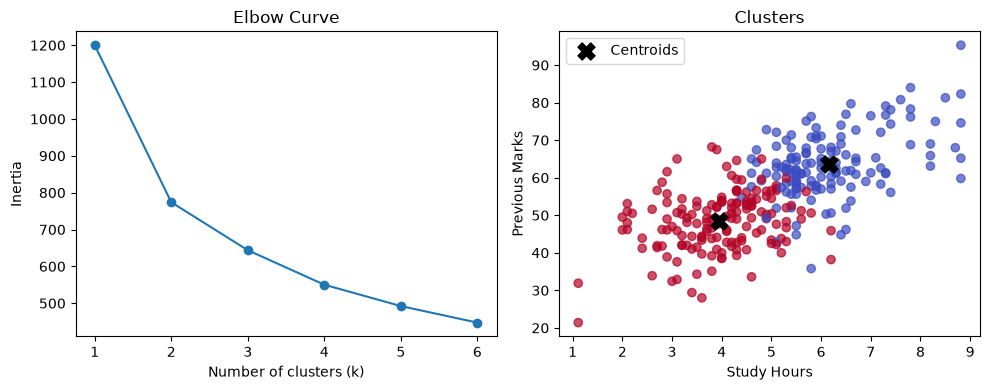

In [14]:
cluster_cols = ["study_hours", "attendance", "previous_marks", "sleep_hours"]
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(df[cluster_cols])

inertias, silhouettes = [], []
for k in range(1, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cluster)
    inertias.append(km.inertia_)
    if k > 1:
        silhouettes.append(silhouette_score(X_cluster, km.labels_))

print("Inertia for k = 1 to 6:", np.round(inertias, 1))
print("Silhouette for k = 2 to 6:", np.round(silhouettes, 3))

# choosing the k with the highest silhouette score
best_k = 2 + int(np.argmax(silhouettes))
final_km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_cluster)

clustered = df[cluster_cols].copy()
clustered["cluster"] = final_km.labels_
print("Best k:", best_k)
print(clustered.groupby("cluster").mean().round(1))
print("Students in each cluster:", clustered["cluster"].value_counts().sort_index().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(1, 7), inertias, marker="o")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

centers = cluster_scaler.inverse_transform(final_km.cluster_centers_)
axes[1].scatter(clustered["study_hours"], clustered["previous_marks"], c=clustered["cluster"], cmap="coolwarm", alpha=0.7)
axes[1].scatter(centers[:, 0], centers[:, 2], color="black", marker="X", s=150, label="Centroids")
axes[1].set_title("Clusters")
axes[1].set_xlabel("Study Hours")
axes[1].set_ylabel("Previous Marks")
axes[1].legend()
plt.tight_layout()
plt.show()

#### What the program does
The program standardizes the four columns and runs K-Means for k = 1 to 6, saving the inertia and the silhouette score each time. It picks the k with the highest silhouette score, fits the final model, and prints the average of each feature in every cluster and the cluster sizes. The left chart is the elbow curve and the right chart shows the students coloured by cluster, with the centroids marked.

#### Why the graph looks like this
In the elbow curve, inertia keeps falling smoothly (from 1200 at k = 1 to 447 at k = 6) and there is no sharp bend. That is because the students are one continuous cloud of points, not separate groups, and any extra cluster just cuts that cloud into smaller pieces. In the scatter plot the two colours split the cloud into a lower-left part (low study hours and low previous marks) and an upper-right part, and the two centroids sit in the middle of each half.

#### Advantages
- Finds groups in the data without needing any labels.
- Cluster averages give a quick way to describe each group.

#### Limitations
- k has to be chosen by us, and the elbow is not always clear.
- Sensitive to scaling and outliers, and it assumes round clusters of similar size.

#### Interpretation
The silhouette score is highest for k = 2 (0.296) and drops after that, so k = 2 is used. A score of about 0.3 means weak to moderate structure, which matches the elbow curve. The two groups are about 144 students with high study hours (6.2), attendance (84.8) and previous marks (63.7), and about 156 students with lower values (3.9, 75.2 and 48.4), while sleep hours are almost the same in both (7.1), so sleep does not separate them.

## Principal Component Analysis (PCA)

### Concept
PCA reduces the number of features by creating new features (principal components) that are combinations of the old ones, ordered by how much of the variation in the data they capture. It is based on the covariance (or correlation) matrix of the features: the eigenvectors are the directions of the components and the eigenvalues are the variance each one explains. It works best when features are correlated, because then several of them can be replaced by one component. The data must be standardized first.

### Example
I have 5 numeric features. If some of them move together, PCA can describe most of the data with fewer than 5 components, which makes models faster and charts possible in 2D.

### Python Implementation

Variance explained by each component: [0.438 0.212 0.188 0.113 0.049]
Cumulative variance explained: [0.438 0.65  0.838 0.951 1.   ]
                 PC1   PC2
study_hours     0.62  0.06
attendance      0.55 -0.01
sleep_hours    -0.05  0.69
previous_marks  0.56 -0.00
age            -0.00  0.72


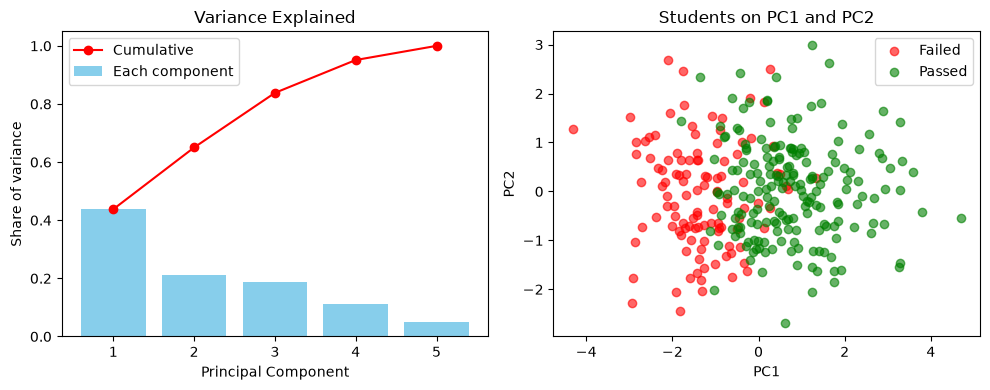

In [15]:
pca_cols = ["study_hours", "attendance", "sleep_hours", "previous_marks", "age"]
X_pca_input = StandardScaler().fit_transform(df[pca_cols])

pca = PCA()
components = pca.fit_transform(X_pca_input)

explained = pca.explained_variance_ratio_
print("Variance explained by each component:", explained.round(3))
print("Cumulative variance explained:", explained.cumsum().round(3))
print(pd.DataFrame(pca.components_[:2].T, index=pca_cols, columns=["PC1", "PC2"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(range(1, 6), explained, color="skyblue", label="Each component")
axes[0].plot(range(1, 6), explained.cumsum(), marker="o", color="red", label="Cumulative")
axes[0].set_title("Variance Explained")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Share of variance")
axes[0].legend()

for label, color, name in [(0, "red", "Failed"), (1, "green", "Passed")]:
    mask = (df["passed"] == label).values
    axes[1].scatter(components[mask, 0], components[mask, 1], color=color, alpha=0.6, label=name)
axes[1].set_title("Students on PC1 and PC2")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()
plt.tight_layout()
plt.show()

#### What the program does
The program standardizes the five features and fits PCA on them. It prints how much variance each component explains, the running total, and the loadings (how much each original feature contributes to PC1 and PC2). The left chart shows the variance explained by each component, and the right chart plots every student on the first two components, coloured by pass or fail.

#### Why the graph looks like this
The bars go down from the first to the last component, with a cumulative line rising to 1. PC1 is the tallest bar (about 44%), because study hours, attendance and previous marks are correlated and move together, so they form one strong direction. The other bars are smaller (21%, 19%, 11% and 5%), and two of the bigger ones (PC2 and PC3) come mostly from sleep hours and age, because these two are not related to anything else, so they cannot be combined with the other features. In the scatter plot, students who passed (green) are more on the right side of PC1 and failed students (red) are on the left, so PC1 is like an overall 'effort' score, while PC2 does not separate them.

#### Advantages
- Reduces the number of features while keeping most of the information.
- Removes the correlation between features.

#### Limitations
- The components are combinations of features, so they are harder to explain.
- Only captures straight-line relationships and needs scaled data.

#### Interpretation
The first component explains 43.8% of the variance and the first two together 65%. It needs 3 components to reach 83.8% and 4 to reach 95.1%, so PCA does not compress this data very strongly. PC1 gets loadings of 0.55 to 0.62 from study_hours, attendance and previous_marks, and PC2 is mostly sleep_hours and age (around 0.7 each).

## Recommendation Systems

### Concept
A recommendation system suggests items a user might like. In collaborative filtering, users who rated things in a similar way in the past are expected to like similar things in the future. Statistics is used to measure how similar two users are (correlation or cosine similarity) and to predict a missing rating as a weighted average of the ratings of similar users, where more similar users get more weight.

### Example
Six learners have rated five courses from 1 to 5, and prasanthi has not rated Statistics and Machine Learning yet. I want to find the learners who rate like prasanthi, and use their ratings to predict what prasanthi would give, then recommend the course with the higher predicted rating.

### Python Implementation

           rafiya  sonia  divya  ramya  bhumi  prasanthi
rafiya       1.00   0.81  -0.94  -0.91   0.87       1.00
sonia        0.81   1.00  -0.89  -0.60   0.87       0.84
divya       -0.94  -0.89   1.00   0.75  -0.70      -0.94
ramya       -0.91  -0.60   0.75   1.00  -0.98      -0.93
bhumi        0.87   0.87  -0.70  -0.98   1.00       1.00
prasanthi    1.00   0.84  -0.94  -0.93   1.00       1.00
Predicted ratings for prasanthi
Machine Learning    4.70
Statistics          4.35
dtype: float64


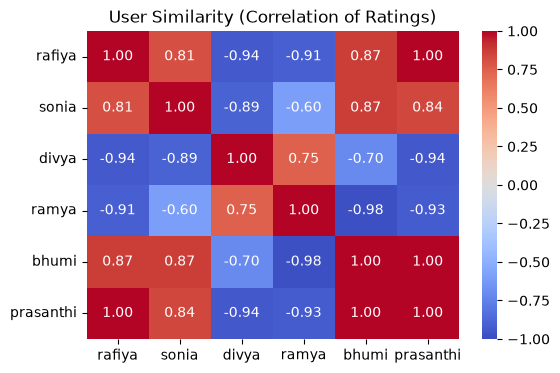

In [16]:
ratings = pd.DataFrame({
    "Python":           [5, 4, 2, 1, 5, 5],
    "SQL":              [4, 5, 2, 3, np.nan, 4],
    "Statistics":       [5, 4, 1, 2, 4, np.nan],
    "Java":             [2, 1, 5, 4, 3, 2],
    "Machine Learning": [5, 4, 2, np.nan, 5, np.nan]
}, index=["rafiya", "sonia", "divya", "ramya", "bhumi", "prasanthi"])

# similarity between users = correlation of their ratings (only on the courses both have rated)
user_similarity = ratings.T.corr()

target_user = "prasanthi"
similarities = user_similarity[target_user].drop(target_user)

predictions = {}
for course in ratings.columns[ratings.loc[target_user].isna()]:
    raters = ratings[course].dropna().index.difference([target_user])
    sim = similarities[raters]
    sim = sim[sim > 0]    # using only users with a positive similarity
    predictions[course] = (sim * ratings.loc[sim.index, course]).sum() / sim.sum()

print(user_similarity.round(2))
print("Predicted ratings for", target_user)
print(pd.Series(predictions).sort_values(ascending=False).round(2))

sns.heatmap(user_similarity, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("User Similarity (Correlation of Ratings)")
plt.show()

#### What the program does
The program creates a small ratings table with some missing ratings, and calculates the correlation between every pair of users. For each course that prasanthi has not rated, it takes the users who rated that course, keeps only the ones with a positive similarity, and calculates the weighted average of their ratings. The result is sorted so the best recommendation is on top, and the heatmap shows the similarity matrix.

#### Why the graph looks like this
The heatmap is red where two users rate alike and blue where they rate in opposite ways. Prasanthi is dark red with rafiya, bhumi and sonia, because they all give high ratings to Python and lower ratings to Java. Prasanthi is dark blue with divya and ramya, who love Java and rate Python low. The matrix is symmetric and the diagonal is 1 (every user is the same as themselves), and divya and ramya are close to each other (0.75) because they like the same kind of courses.

#### Advantages
- Uses only the ratings, so it needs no information about the items.
- Easy to explain with correlation and a weighted average.

#### Limitations
- Similarity is calculated from very few common courses (prasanthi and bhumi have only 2 in common, and any 2 points give a correlation of exactly 1 or -1), so it can look more certain than it is.
- New users with no ratings cannot get recommendations (cold start).

#### Interpretation
Machine Learning gets a predicted rating of 4.7 and Statistics gets 4.35 (both mostly from rafiya, bhumi and sonia), so Machine Learning should be recommended first. Users with a negative similarity (divya and ramya) are ignored, because their opinion goes in the opposite direction.

## Interview Questions

**1. Why is the median usually preferred over the mean for filling missing values?**</br>

The median is not affected by outliers, while the mean is pulled toward extreme values. When a column has outliers or is skewed, the median is a more typical value to use. For categorical columns the mode is used instead.

**2. Why did the Z-score method find fewer outliers than the IQR method here?**</br>

The Z-score depends on the mean and standard deviation, and extreme values increase both of them, so they partly hide themselves. The IQR method uses quartiles, which are not affected by extreme values, so it is more robust.

**3. What is the difference between standardization and normalization?**</br>

Standardization uses the mean and standard deviation to give a mean of 0 and a standard deviation of 1. Normalization (min-max) uses the minimum and maximum to squeeze values into a fixed range, usually 0 to 1. Min-max is more sensitive to outliers.

**4. Why should the scaler be fitted only on the training data?**</br>

If the scaler uses the test data to calculate the mean and standard deviation, information from the test set leaks into training and the evaluation becomes too optimistic. The scaler should learn from the training data only and then be applied to the test data.

**5. What does R-squared tell you, and why compare it with a baseline?**</br>

R-squared is the share of the variation in the target that the model explains. A model that always predicts the mean has an R-squared of about 0, so this baseline shows the minimum that any useful model must beat.

**6. What is the difference between Linear Regression and Logistic Regression?**</br>

Linear regression predicts a number using a straight line and is judged with metrics like RMSE and R-squared. Logistic regression predicts the probability of a class by passing a linear score through the sigmoid function, and is judged with accuracy, precision, recall and the confusion matrix.

**7. Why is Naive Bayes called 'naive'?**</br>

Because it assumes that all features are independent of each other given the class. This is rarely true in real data (here study hours, attendance and previous marks are correlated), but it makes the calculation simple and it still often works reasonably well.

**8. How do you choose the number of clusters in K-Means?**</br>

By looking at the elbow curve of the inertia and at the silhouette score, and by checking if the clusters make sense for the problem. A high silhouette score means well-separated clusters, while a score around 0.3 means weak structure.

**9. What does the explained variance ratio in PCA tell you?**</br>

It tells how much of the total variation in the data each principal component captures. The cumulative value shows how many components are needed to keep most of the information, for example 95% of the variance.

**10. How is correlation used in a recommendation system?**</br>

In collaborative filtering, the correlation between the ratings of two users measures how similar their taste is. The rating of a missing item is then predicted as a weighted average of the ratings of the most similar users.